# Employee Attrition & Retention Analytics Dataset Analysis and Prediction

## Summary

In this notebook i take a look at the [Employee Attrition & Retention Analytics Dataset](https://www.kaggle.com/datasets/ajinkyachintawar/employee-attrition-and-retention-analytics-dataset/data) and predict the Attrition (left the Company or not) from the Features.

- 

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../Datasets/HR-Employee-Attrition.csv")

## Data Loading

In [39]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,49,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,2.0,...,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,5.0,...,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,...,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1476 non-null   object 
 1   Attrition                 1476 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

In [41]:
#Convert Age to numeric type
df["Age"] = pd.to_numeric(df['Age'],errors="coerce")

In [42]:
df.isnull().sum()
#since there a six values missing we will drop them
df.dropna(inplace=True)
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Exploratory Data Analysis

In [43]:
# Numeric columns
num_list = df.select_dtypes(include=np.number).columns.tolist()
print(num_list)
# Object Columns
obj_list = df.select_dtypes(include="object").columns.tolist()
print(obj_list)

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


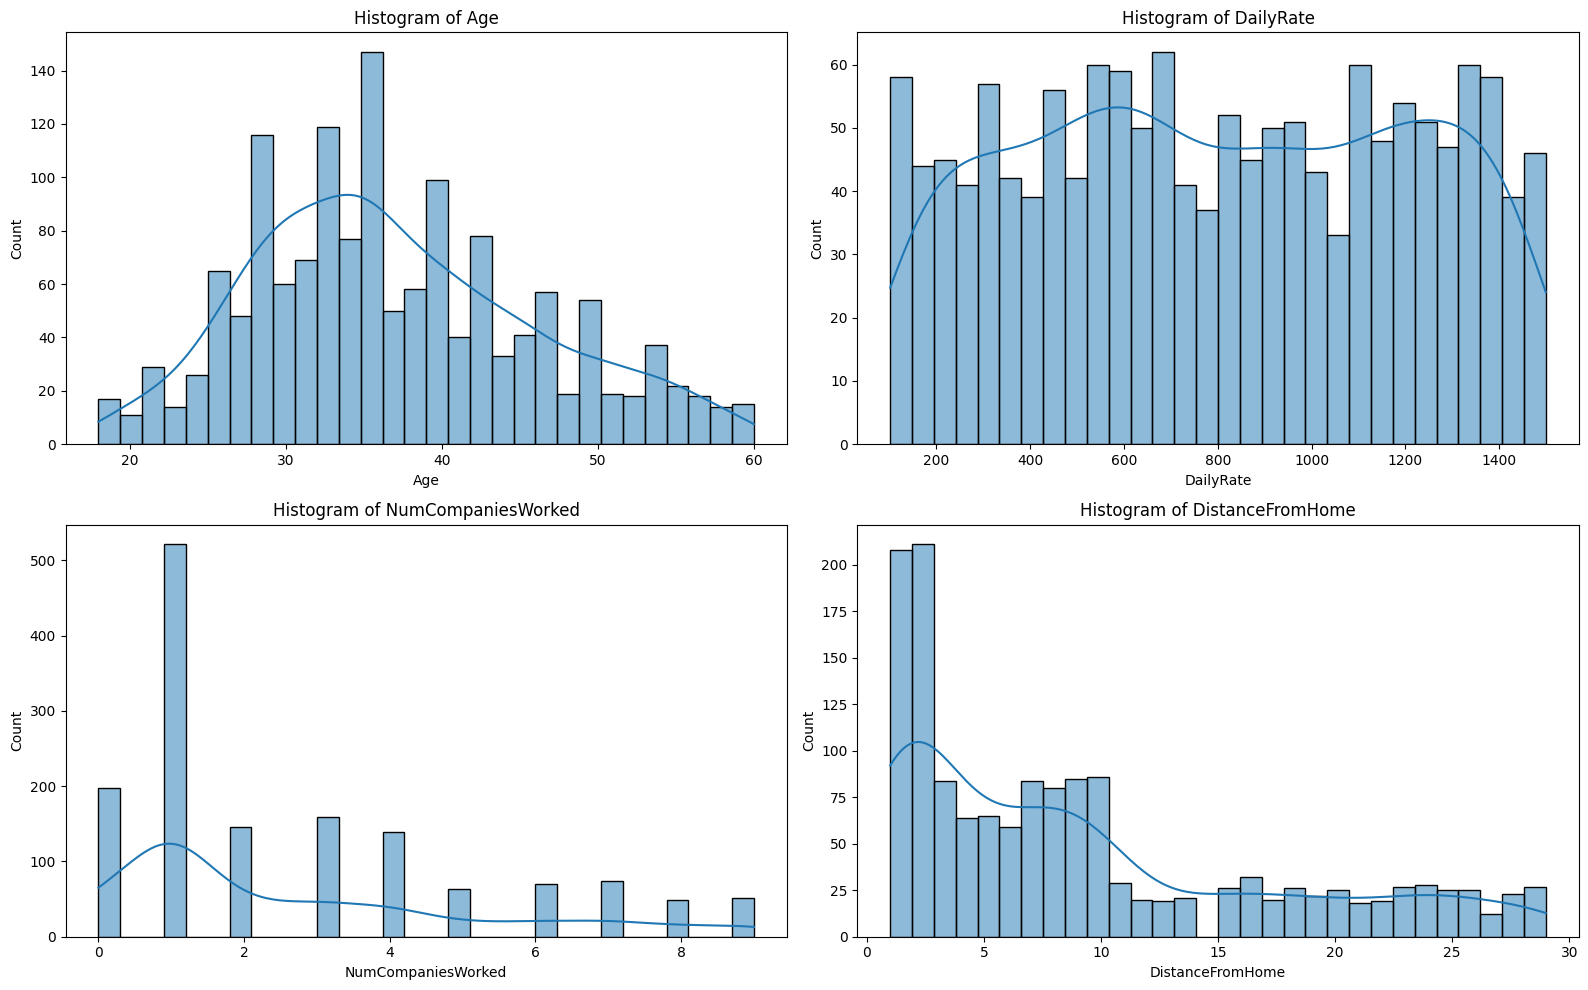

In [80]:
# lets select a few numeric columns to plot them
import math
num_list=['Age',"DailyRate","NumCompaniesWorked",'DistanceFromHome']

#Histplots
ncols = 2
nrows = math.ceil(len(num_list) / ncols)

plt.figure(figsize=(16, nrows * 5))
for i, col in enumerate(num_list):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data=df,x=col, kde=True, bins=30)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


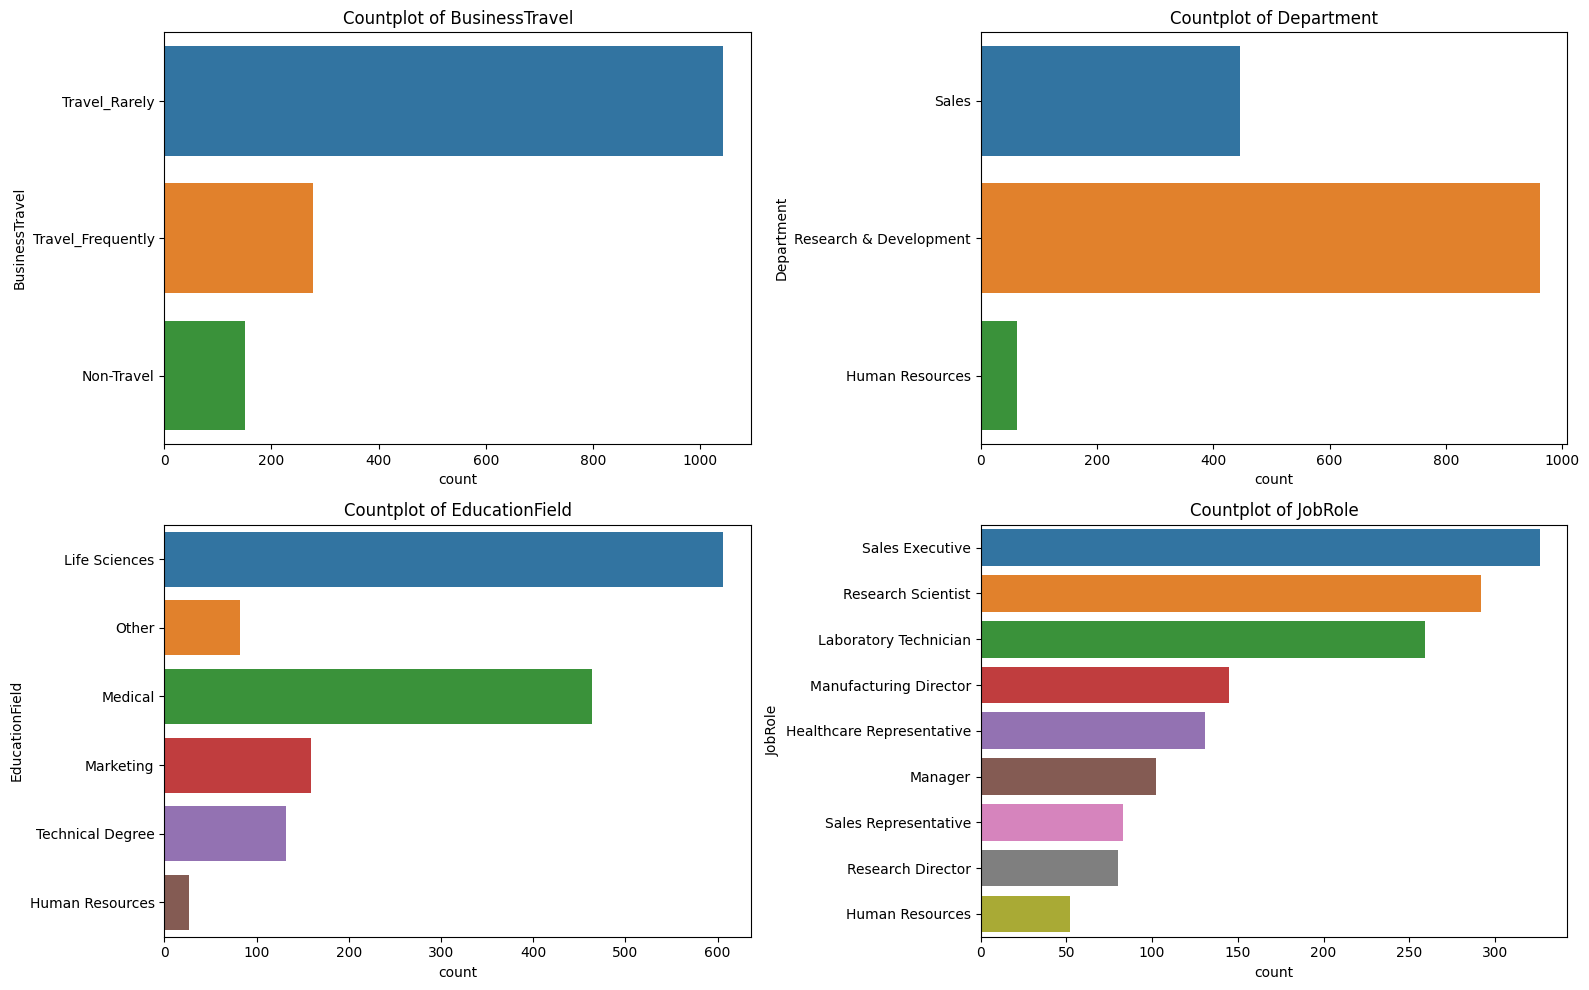

In [85]:
# Categorical Values
obj_list=['BusinessTravel', 'Department', 'EducationField',"JobRole"]

ncols = 2
nrows = math.ceil(len(obj_list) / ncols)

plt.figure(figsize=(16,nrows*5))
for i, obj in enumerate(obj_list):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.countplot(data=df,y=obj,hue=obj,legend=False)
    ax.set_title(f"Countplot of {obj}")

plt.tight_layout()
plt.show()



## Preprocessing for Training

In [ ]:
# Use one hot encoder